In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
# import countrycode

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [46]:
model = "meta-llama/llama-4-scout-17b-16e-instruct"
MODEL_NAME = model
nb_rep = 50
# res_savename = f"llm_response_impact_test_range_hazmain_nb_format_std_units_cont_units_{nb_rep}rep_{MODEL_NAME.replace('/', '_')}"#.csv"
# res_savename = f"llm_response_hazmain_nb_format_std_units_impact_{nb_rep}rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
res_savename = f"post_processed_llm_response_impact_labelled_reports_{MODEL_NAME.replace('/', '_')}"
# res_savename_labelled = 
print(res_savename)
response_df = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

post_processed_llm_response_impact_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct


In [5]:
# model = "meta-llama/llama-4-scout-17b-16e-instruct"
# MODEL_NAME = model
# nb_rep = 300
# # res_savename = f"llm_response_impact_test_range_hazmain_nb_format_std_units_cont_units_{nb_rep}rep_{MODEL_NAME.replace('/', '_')}"#.csv"
# res_savename = f"llm_response_hazmain_nb_format_std_units_impact_{nb_rep}rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
# print(res_savename)
# response_df_300 = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# # response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

# Convert location to polygons

In [7]:
# model = "meta-llama/llama-4-scout-17b-16e-instruct"
# MODEL_NAME = model
# res_savename = f"llm_response_hazmain_nb_format_std_units_impact_300rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
# print(res_savename)
# response_df = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# # response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

In [10]:
df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_reports_impacts_luca.csv', encoding='utf-8')
df_labelled_laura = pd.read_csv(DATA_LABELLED+"labelled_8reports_impact_laura.csv", encoding='utf-8')
df_labelled = pd.concat([df_labelled_luca, df_labelled_laura], ignore_index=True)

In [11]:
# response_df_geo = gpd.read_file(DATA_OUT_LLMS + res_savename+"_geo.gpkg")

In [8]:
gpd_files = open_admin_gpd(ADMIN_PATH)

In [4]:
# df_row_append.loc["locationPolygon"] = merged_geometry
#             df_row_append.loc["locationLowestAdmin"] = layer_name
#             downgrade_flag = 1 if (df_locations["geocoding_country_flag"] == 1).any() else 0
#             df_row_append.loc["geocoding_country_flag"] = downgrade_flag

In [35]:
df = response_df#.iloc[:2]
df_geo = deepcopy(df)
df_geo_output = pd.DataFrame(columns = list(df.columns)+["locationPolygon", "locationLowestAdmin", "geocoding_country_flag", "geocoding_osm_flag", "locationGeo"])
# for col in ["location", "country", "country_kw"]: 
#     df_geo[col] = dµf_geo[col].apply(lambda x: ast.literal_eval(x) 
#                                                   if pd.notna(x) and isinstance(x, str) and x.startswith("[") 
#                                                   else ([x] if pd.notna(x) else x))
#     df_geo[col] = df_geo[col].apply(lambda x: None if pd.isna(x) else (x))
for col in ["location", "country", "country_kw"]: 
    df_geo[col] = df_geo[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
    )
time_last_request = time.time()

In [36]:
#Constants 
gather_admin_level=True
similarity_th=0.2
similarity_polygon = 0.9
print_info=False
DATA_OUT_LLMS=DATA_OUT_LLMS
res_savename=res_savename

In [37]:
for row_index, row_data in df_geo.iterrows():
    try : 
        geocoding_country_flag = None
        geocoding_osm_flag = None
        locations = row_data['location']
        country = row_data["country"]
        if not country : 
            country = row_data["country_kw"]

        # If no country is found, don't look for any polygon 
        if not country:
            df_row_append = df_geo.loc[row_index].copy()
            df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
            continue

        # If no location, change to have it as a list
        if not locations : 
            locations = [None]
            
        # if isinstance(locations, float) : 
        #     locations = [None]
        df_locations = []

        # print(f"Geocode {locations} {country}")
        for location in locations : 
            # print("Run unique geocoding with : ", location, country)
            df_loc = geocode_unique_loc(gpd_files, location, country, similarity_th, time_last_request, print_info)
            # print("Output columns of geocoding", df_loc.columns)
            time_last_request = time.time()
            if df_loc is not None : 
                if geocoding_country_flag is not None : 
                    df_loc["geocoding_country_flag"] = geocoding_country_flag
                if geocoding_osm_flag is not None : 
                    df_loc["geocoding_osm_flag"] = geocoding_osm_flag
                df_locations.append(df_loc)   
        if not df_locations : 
            continue
            
        df_locations = pd.concat(df_locations, axis=0)
        df_locations = df_locations[df_locations['geometry'].notnull()]
        if df_locations.empty:
            continue
        # print("Df location : ", df_locations)
            
        #Retrieve the lowest admin level
        lowest_level = df_locations["finest_level"].min()
        highest_level = df_locations["finest_level"].max()
        
        #Merge all the locs to the lewest admin levels
        # print("MERGE AT ADMIN LEVEL")
        for merge_level in range(lowest_level, highest_level+1) :
            # print(f"ADM_{merge_level}")
            layer_name = f"ADM_{merge_level}"
            # print("df_locations for the merge : ", df_locations.loc[df_locations.finest_level>=merge_level])
            merged_geometry = gather_to_lowest_admin(df_locations.loc[df_locations.finest_level>=merge_level], gpd_files, merge_level)
            
            df_row_append = df_geo.loc[row_index].copy()
            df_row_append.loc["locationPolygon"] = merged_geometry
            df_row_append.loc["locationLowestAdmin"] = layer_name
            downgrade_country_flag = 1 if (df_locations["geocoding_country_flag"] == 1).any() else 0
            df_row_append.loc["geocoding_country_flag"] = downgrade_country_flag
            downgrade_osm_flag = 1 if (df_locations["geocoding_osm_flag"] == 1).any() else 0
            df_row_append.loc["geocoding_osm_flag"] = downgrade_osm_flag

            # Remove the impact value if it's not the lowest admin level
            if merge_level != lowest_level : 
                df_row_append.loc["impactValue"] = np.nan
                df_row_append.loc["impactUnit"] = np.nan
                df_row_append.loc["impactValueApprox"] = np.nan
                
            # Align columns to df_geo_output
            # print("Modify the row")
            df_row_append = pd.DataFrame([df_row_append])
            common_cols = df_geo_output.columns.intersection(df_row_append.columns)
            df_row_append = df_row_append[common_cols]
            
            # print("Make the concat")
            df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
            # print("df_geo_output : ", df_geo_output)
        
        # if gather_admin_level:
        #     merged_geometry = gather_to_lowest_admin(df_locations, gpd_files, lowest_level)
        # else:
        #     merged_geometry = unary_union(df_locations["geometry"])

        # #Update the final database
        # df_geo.loc[row_index, "locationPolygon"] = merged_geometry
        # df_geo.loc[row_index, "locationLowestAdmin"] = layer_name
        # downgrade_flag = 1 if (df_locations["geocoding_country_flag"] == 1).any() else 0
        # df_geo.loc[row_index, "geocoding_country_flag"] = downgrade_flag
        
        # Save 
        # print("Saving step")
        if DATA_OUT_LLMS and res_savename:
            # print(
            save_df = df_geo_output.copy()
            save_df["location"] = save_df["location"].apply(lambda x: str(x) if isinstance(x, list) else x)
            save_df["locationGeo"] = save_df["locationGeo"].apply(lambda x: str(x) if isinstance(x, list) else x)
            save_df["country"] = save_df["country"].apply(lambda x: str(x) if isinstance(x, list) else x)
            save_df["country_kw"] = save_df["country_kw"].apply(lambda x: str(x) if isinstance(x, list) else x)            
            save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')
            try:
                suffix = "_geo_gather" if gather_admin_level else "_geo"
                save_gdf.to_file(f"{DATA_OUT_LLMS}{res_savename}{suffix}.gpkg",
                                 layer="multipolygons", driver="GPKG")
            except Exception as e:
                print(f"[GeoPackage Save Error] {e}")
                
    except Exception as e : 
        print(f"[Row {row_index}] Error: {e}")
        continue
        
# df_geo_output["location"] = df_geo_output["location"].apply(lambda x: str(x) if isinstance(x, list) else x)

[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[get_polygon] Error: first argument must be string or compiled pattern
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: '

In [47]:
#SAVE to GPKG
save_df = df_geo_output.copy()
save_df["location"] = save_df["location"].apply(lambda x: str(x) if isinstance(x, list) else x)
save_df["locationGeo"] = save_df["locationGeo"].apply(lambda x: str(x) if isinstance(x, list) else x)
save_df["country"] = save_df["country"].apply(lambda x: str(x) if isinstance(x, list) else x)
save_df["country_kw"] = save_df["country_kw"].apply(lambda x: str(x) if isinstance(x, list) else x)            
save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')
try:
    suffix = "_geo" #"_geo_gather" if gather_admin_level else "_geo"
    save_gdf.to_file(f"{DATA_OUT_LLMS}{res_savename}{suffix}.gpkg",
                     layer="multipolygons", driver="GPKG")
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

In [52]:
#Do the same for the labelled ones 
df = df_labelled#.iloc[:2]
df_geo = deepcopy(df)
df_geo_output = pd.DataFrame(columns = list(df.columns)+["locationPolygon", "locationLowestAdmin", "geocoding_country_flag", "geocoding_osm_flag", "locationGeo"])
# for col in ["location", "country", "country_kw"]: 
#     df_geo[col] = dµf_geo[col].apply(lambda x: ast.literal_eval(x) 
#                                                   if pd.notna(x) and isinstance(x, str) and x.startswith("[") 
#                                                   else ([x] if pd.notna(x) else x))
#     df_geo[col] = df_geo[col].apply(lambda x: None if pd.isna(x) else (x))
for col in ["location", "country"]: 
    df_geo[col] = df_geo[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
    )
time_last_request = time.time()

In [53]:
#Constants 
gather_admin_level=True
similarity_th=0.2
similarity_polygon = 0.9
print_info=False
DATA_OUT_LLMS=DATA_LABELLED
res_savename_labelled="labelled_reports_impacts_geo"

In [54]:
for row_index, row_data in df_geo.iterrows():
    try : 
        geocoding_country_flag = None
        geocoding_osm_flag = None
        locations = row_data['location']
        country = row_data["country"]
        # if not country : 
        #     country = row_data["country_kw"]

        # If no country is found, don't look for any polygon 
        if not country:
            df_row_append = df_geo.loc[row_index].copy()
            df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
            continue

        # If no location, change to have it as a list
        if not locations : 
            locations = [None]
            
        # if isinstance(locations, float) : 
        #     locations = [None]
        df_locations = []

        # print(f"Geocode {locations} {country}")
        for location in locations : 
            # print("Run unique geocoding with : ", location, country)
            df_loc = geocode_unique_loc(gpd_files, location, country, similarity_th, time_last_request, print_info)
            # print("Output columns of geocoding", df_loc.columns)
            time_last_request = time.time()
            if df_loc is not None : 
                if geocoding_country_flag is not None : 
                    df_loc["geocoding_country_flag"] = geocoding_country_flag
                if geocoding_osm_flag is not None : 
                    df_loc["geocoding_osm_flag"] = geocoding_osm_flag
                df_locations.append(df_loc)   
        if not df_locations : 
            continue
            
        df_locations = pd.concat(df_locations, axis=0)
        df_locations = df_locations[df_locations['geometry'].notnull()]
        if df_locations.empty:
            continue
        # print("Df location : ", df_locations)
            
        #Retrieve the lowest admin level
        lowest_level = df_locations["finest_level"].min()
        highest_level = df_locations["finest_level"].max()
        
        #Merge all the locs to the lewest admin levels
        # print("MERGE AT ADMIN LEVEL")
        for merge_level in range(lowest_level, highest_level+1) :
            # print(f"ADM_{merge_level}")
            layer_name = f"ADM_{merge_level}"
            # print("df_locations for the merge : ", df_locations.loc[df_locations.finest_level>=merge_level])
            merged_geometry = gather_to_lowest_admin(df_locations.loc[df_locations.finest_level>=merge_level], gpd_files, merge_level)
            
            df_row_append = df_geo.loc[row_index].copy()
            df_row_append.loc["locationPolygon"] = merged_geometry
            df_row_append.loc["locationLowestAdmin"] = layer_name
            downgrade_country_flag = 1 if (df_locations["geocoding_country_flag"] == 1).any() else 0
            df_row_append.loc["geocoding_country_flag"] = downgrade_country_flag
            downgrade_osm_flag = 1 if (df_locations["geocoding_osm_flag"] == 1).any() else 0
            df_row_append.loc["geocoding_osm_flag"] = downgrade_osm_flag

            # Remove the impact value if it's not the lowest admin level
            if merge_level != lowest_level : 
                df_row_append.loc["impactValue"] = np.nan
                df_row_append.loc["impactUnit"] = np.nan
                df_row_append.loc["impactValueApprox"] = np.nan
                
            # Align columns to df_geo_output
            # print("Modify the row")
            df_row_append = pd.DataFrame([df_row_append])
            common_cols = df_geo_output.columns.intersection(df_row_append.columns)
            df_row_append = df_row_append[common_cols]
            
            # print("Make the concat")
            df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
            # print("df_geo_output : ", df_geo_output)
        
        # if gather_admin_level:
        #     merged_geometry = gather_to_lowest_admin(df_locations, gpd_files, lowest_level)
        # else:
        #     merged_geometry = unary_union(df_locations["geometry"])

        # #Update the final database
        # df_geo.loc[row_index, "locationPolygon"] = merged_geometry
        # df_geo.loc[row_index, "locationLowestAdmin"] = layer_name
        # downgrade_flag = 1 if (df_locations["geocoding_country_flag"] == 1).any() else 0
        # df_geo.loc[row_index, "geocoding_country_flag"] = downgrade_flag
        
        # Save 
        # print("Saving step")
        if DATA_OUT_LLMS and res_savename:
            # print(
            save_df = df_geo_output.copy()
            save_df["location"] = save_df["location"].apply(lambda x: str(x) if isinstance(x, list) else x)
            save_df["locationGeo"] = save_df["locationGeo"].apply(lambda x: str(x) if isinstance(x, list) else x)
            save_df["country"] = save_df["country"].apply(lambda x: str(x) if isinstance(x, list) else x)
            # save_df["country_kw"] = save_df["country_kw"].apply(lambda x: str(x) if isinstance(x, list) else x)            
            save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')
            try:
                suffix = "_geo"#"_geo_gather" if gather_admin_level else "_geo"
                save_gdf.to_file(f"{DATA_OUT_LLMS}{res_savename_labelled}{suffix}.gpkg",
                                 layer="multipolygons", driver="GPKG")
            except Exception as e:
                print(f"[GeoPackage Save Error] {e}")
                
    except Exception as e : 
        print(f"[Row {row_index}] Error: {e}")
        continue
        
# df_geo_output["location"] = df_geo_output["location"].apply(lambda x: str(x) if isinstance(x, list) else x)

[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'


ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons


[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[gather admin fallback] Error: 'ADM_1'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extensio

ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons


[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'


...

[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'


ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons


[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (ta

ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed: no such table: multipolygons
ERROR 1: sqlite3_prepare_v2(SELECT Count(*) FROM "multipolygons") failed:

[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (table_name TEXT,column_name TEXT,extension_name TEXT NOT NULL,definition TEXT NOT NULL,scope TEXT NOT NULL,CONSTRAINT ge_tce UNIQUE (table_name, column_name, extension_name))) failed: database is locked'
[GeoPackage Save Error] b'sqlite3_exec(CREATE TABLE gpkg_extensions (ta

In [59]:
df_geo_output

,reportDate,impactSubType,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,country,location,startYear,...,hazards,annotation,comments,appealCode,impactSubtype,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationGeo
0,2025-03-28,Affected People,326788.0,people,exact,NaN,NaN,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa, Sindh]",2024.0,...,['Flood'],['(Photo PRCS NHQ) Appeal MDRPK026 Total DREF ...,NaN,MDRPK026,NaN,MULTIPOLYGON (((67.11349487408933 24.685400008...,ADM_1,0,0,NaN
1,2025-03-28,Other Infrastructure Impacts,NaN,people,approx,NaN,NaN,[Pakistan],[],2024.0,...,[],['Pakistan endured an exceptionally intense mo...,NaN,MDRPK026,NaN,MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,NaN
2,2025-03-28,Human Deaths,NaN,people,approx,NaN,NaN,[Pakistan],[],2024.0,...,[],['Pakistan endured an exceptionally intense mo...,NaN,MDRPK026,NaN,MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,NaN
3,2025-03-28,Injured People,NaN,people,approx,NaN,NaN,[Pakistan],[],2024.0,...,[],['Pakistan endured an exceptionally intense mo...,NaN,MDRPK026,NaN,MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,NaN
4,2025-03-28,Affected People,109602.0,people,approx,109602.0,NaN,[Pakistan],[Balochistan],2024.0,...,"['Flood', 'Mass Movement']","['In Balochistan, rainfall levels surged by 23...",NaN,MDRPK026,NaN,MULTIPOLYGON (((63.84086990382309 25.118297577...,ADM_1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,[Yemen],"[Al-Mahra, Al-Mahwit, Hadramout, Dhamar, Al-Ba...",2022.0,...,"['Flood', 'Other storm']",['Based on YRCS and shelter cluster flood trac...,NaN,MDRYE011,Other Economic & Livelihood impact,GEOMETRYCOLLECTION EMPTY,ADM_1,1,0,NaN
464,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,[Yemen],"[Al-Mahra, Al-Mahwit, Hadramout, Dhamar, Al-Ba...",2022.0,...,"['Flood', 'Other storm']",['Based on YRCS and shelter cluster flood trac...,NaN,MDRYE011,Other Economic & Livelihood impact,POLYGON ((45.296230000114576 15.35311999998811...,ADM_2,1,0,NaN
465,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,[Yemen],"[Al-Mahra, Al-Mahwit, Hadramout, Dhamar, Al-Ba...",2022.0,...,"['Flood', 'Other storm']",['Based on YRCS and shelter cluster flood trac...,NaN,MDRYE011,"Water, Sanitation, and Hygiene Infrastructure",MULTIPOLYGON (((42.74390709700003 13.688421942...,ADM_0,1,0,NaN
466,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,[Yemen],"[Al-Mahra, Al-Mahwit, Hadramout, Dhamar, Al-Ba...",2022.0,...,"['Flood', 'Other storm']",['Based on YRCS and shelter cluster flood trac...,NaN,MDRYE011,"Water, Sanitation, and Hygiene Infrastructure",GEOMETRYCOLLECTION EMPTY,ADM_1,1,0,NaN


In [63]:
import os

In [67]:
#SAVE to GPKG
save_df = df_geo_output.copy()
save_df["location"] = save_df["location"].apply(lambda x: str(x) if isinstance(x, list) else x)
save_df["locationGeo"] = save_df["locationGeo"].apply(lambda x: str(x) if isinstance(x, list) else x)
save_df["country"] = save_df["country"].apply(lambda x: str(x) if isinstance(x, list) else x)       

save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')

save_gdf = save_gdf[~save_gdf["locationPolygon"].is_empty & save_gdf["locationPolygon"].notnull()]
save_gdf = save_gdf[save_gdf.is_valid]

try:
    suffix = "_geo" #"_geo_gather" if gather_admin_level else "_geo"
    filepath = f"{DATA_OUT_LLMS}{res_savename_labelled}.gpkg"
    if os.path.exists(filepath):
        os.remove(filepath)
    save_gdf.to_file(filepath,
                     layer="multipolygons", driver="GPKG", ENGINE_OPTS={"SPATIAL_INDEX": "NO"})
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

/home/lhasbini/.conda/envs/dev/lib/python3.11/site-packages/geopandas/geoseries.py:779: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


[GeoPackage Save Error] b'gdal_sqlite_rtree_bl_from_feature_table() failed with no such table: multipolygons'


In [29]:
len(response_df)

275

In [ ]:
type(df_geo_output['

In [56]:
# Try to make query to obtain a polygon 
geolocator = gpy.geocoders.Nominatim(user_agent='orienternet')
location = "Al Ansar Daira"
country = "Algeria"
query = f"{location}, {country}"
query = f"{country}"
result = geolocator.geocode(query, exactly_one=True, language="en", addressdetails =True, geometry="geojson")

In [198]:
# result.raw

In [195]:
gpd_files["ADM_2"].loc[(gpd_files["ADM_2"]["ADMIN_0"]=="Algeria") & (gpd_files["ADM_2"]["ADMIN_1"]=="Batna") & (gpd_files["ADM_2"]["ADMIN_2"]=="Batna")]

,iso3_code,map_code,gaul0_code,ADMIN_0,gaul1_code,ADMIN_1,gaul2_code,ADMIN_2,continent,disp_en,geometry
169,DZA,DZA,101,Algeria,1006,Batna,100167,Batna,Africa,"Batna, Batna, Algeria","POLYGON ((6.14213 35.63423, 6.14225 35.62781, ..."


In [199]:
from shapely.geometry import Polygon
result_polygon = pd.DataFrame(result.raw['geojson']['coordinates']).transpose().apply(Polygon)

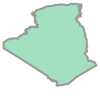

In [200]:
result_polygon[0]

In [57]:
df_geo

,impactSubtype,impactValue,impactUnit,impactValueApprox,country,location,startYear,startMonth,startDay,endYear,...,endDay,hazards,impactsAnnotation,impactValueMin,impactValueMax,appealCode,country_kw,reportDate,disasterType,nathaz_text
0,Affected People,45000.0,people,exact,[Indonesia],"[Java, Nusa Tenggara, Bali, Kalimantan, Sumatra]",2023.0,8.0,NaN,2024.0,...,NaN,['Drought'],['The drought operation aimed to address the i...,45000.0,45000.0,MDRID026,[Indonesia],2025-05-14 00:00:00,Drought,['Page 1 / 24 Description of the Event Map of ...
1,Human Health and Wellbeing,NaN,NaN,NaN,[Indonesia],"[Bali, East Nusa Tenggara, West Nusa Tenggara,...",2023.0,12.0,NaN,2024.0,...,NaN,['Drought'],['Communities in the affected areas primarily ...,NaN,NaN,MDRID026,[Indonesia],2025-05-14 00:00:00,Drought,['Page 1 / 24 Description of the Event Map of ...


In [58]:
df_geo_output

,impactSubtype,impactValue,impactUnit,impactValueApprox,country,location,startYear,startMonth,startDay,endYear,...,appealCode,country_kw,reportDate,disasterType,nathaz_text,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationGeo
0,Affected People,45000.0,people,exact,[Indonesia],"[Java, Nusa Tenggara, Bali, Kalimantan, Sumatra]",2023.0,8.0,NaN,2024.0,...,MDRID026,[Indonesia],2025-05-14 00:00:00,Drought,['Page 1 / 24 Description of the Event Map of ...,MULTIPOLYGON (((100.11524498800003 -2.82789478...,ADM_0,1,0,NaN
1,Affected People,NaN,NaN,NaN,[Indonesia],"[Java, Nusa Tenggara, Bali, Kalimantan, Sumatra]",2023.0,8.0,NaN,2024.0,...,MDRID026,[Indonesia],2025-05-14 00:00:00,Drought,['Page 1 / 24 Description of the Event Map of ...,MULTIPOLYGON (((108.88322449991085 -7.74886119...,ADM_1,1,0,NaN
2,Human Health and Wellbeing,NaN,NaN,NaN,[Indonesia],"[Bali, East Nusa Tenggara, West Nusa Tenggara,...",2023.0,12.0,NaN,2024.0,...,MDRID026,[Indonesia],2025-05-14 00:00:00,Drought,['Page 1 / 24 Description of the Event Map of ...,MULTIPOLYGON (((111.65058900018226 -8.38300129...,ADM_1,0,0,NaN


In [80]:
from shapely.geometry import Polygon
result_polygon = pd.DataFrame(result.raw['geojson']['coordinates']).transpose().apply(Polygon)

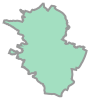

In [85]:
result_polygon[0]

In [89]:
result_polygon_old = get_polygon(gpd_files[f"ADM_2"], country, f"ADMIN_2", 'Kota Malang', 2)

<Axes: >

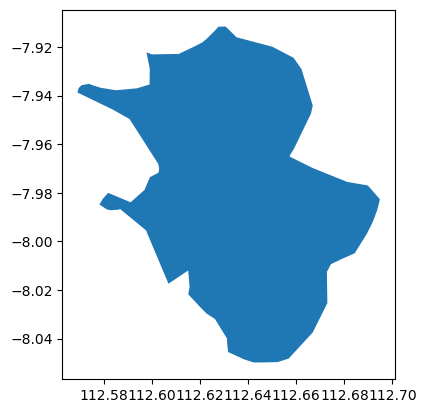

In [92]:
result_polygon_old.geometry.plot()

In [17]:
location = "Java" 
country = "Indonesia"

In [22]:
response_df_geo = geocode_unique_loc(gpd_files, location, country, similarity_th, time_last_request, print_info=True)

Query nominatim :  Java Indonesia
Found geocoding at resolution 1, Initial: Java, Geocoded: Java, Similarity: 1.00
Found geocoding at resolution 0, Initial: Java, Geocoded: Indonesia, Similarity: 0.11
Best match: Java (sim=1.00) at level 1


In [23]:
response_df_geo

,iso3_code,map_code,gaul0_code,ADMIN_0,gaul1_code,ADMIN_1,continent,disp_en,geometry,finest_level,location,geocoding_flag
1110,IDN,IDN,241,Indonesia,2623,Jawa Barat,Asia,"Jawa Barat, Indonesia","MULTIPOLYGON (((108.68501 -6.76990, 108.68411 ...",1,Java,0
1111,IDN,IDN,241,Indonesia,2624,Jawa Tengah,Asia,"Jawa Tengah, Indonesia","MULTIPOLYGON (((108.88353 -7.74846, 108.88322 ...",1,Java,0
1112,IDN,IDN,241,Indonesia,2625,Jawa Timur,Asia,"Jawa Timur, Indonesia","MULTIPOLYGON (((114.20384 -8.65725, 114.20366 ...",1,Java,0


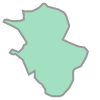

In [157]:
response_df_geo.iloc[0].geometry

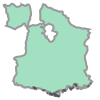

In [158]:
response_df_geo.iloc[1].geometry

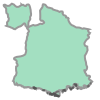

In [169]:
from shapely.ops import unary_union
unary_union([response_df_geo.iloc[0].geometry, response_df_geo.iloc[1].geometry])

In [189]:
response_df_geo = geocode_df_to_polygon(response_df.loc[:2], DATA_OUT_LLMS=DATA_OUT_LLMS, res_savename="test_save")

Open gpd files
Loop locations
Locations :  ['Java', 'Nusa Tenggara', 'Bali', 'Kalimantan', 'Sumatra']
Country :  ['Indonesia'] Type <class 'list'>
Run unique geocoding with :  Java ['Indonesia']
Query nominatim :  Java Indonesia
df unique loc         featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
0  Admin-0 country          0          2  Indonesia    IDN         0      2   

                TYPE TLC    ADMIN_0  ... FCLASS_GR  FCLASS_IT FCLASS_NL  \
0  Sovereign country   1  Indonesia  ...      None       None      None   

  FCLASS_SE  FCLASS_BD FCLASS_UA  \
0      None       None      None   

                                            geometry  finest_level   location  \
0  MULTIPOLYGON (((102.33237 -5.47226, 102.32447 ...             0  Indonesia   

  geocoding_flag  
0              1  

[1 rows x 172 columns]
Run unique geocoding with :  Nusa Tenggara ['Indonesia']
Query nominatim :  Nusa Tenggara Indonesia
df unique loc         featurecla  scalerank  LABE

/home/lhasbini/como_school/como_project4/src/geocoding.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
/home/lhasbini/como_school/como_project4/src/geocoding.py:375: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/lhasbini/como_school/como_project4/src/geocoding.py:377: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_geometry = gather_to_lowest

impactSubtype                                            Affected People
impactValue                                                      45000.0
impactUnit                                                        people
impactValueApprox                                                  exact
country                                                      [Indonesia]
location                [Java, Nusa Tenggara, Bali, Kalimantan, Sumatra]
startYear                                                         2023.0
startMonth                                                           8.0
startDay                                                             NaN
endYear                                                           2024.0
endMonth                                                             6.0
endDay                                                               NaN
hazards                                                      ['Drought']
impactsAnnotation      ['The drought operation aime

/home/lhasbini/como_school/como_project4/src/geocoding.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
/home/lhasbini/como_school/como_project4/src/geocoding.py:375: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/lhasbini/como_school/como_project4/src/geocoding.py:377: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_geometry = gather_to_lowest

[Row 1] Error: Unknown column locationPolygon
Locations :  nan
Country :  nan Type <class 'float'>
[Row 2] Error: 'float' object is not iterable


In [187]:
response_df_geo.head()

,impactSubtype,impactValue,impactUnit,impactValueApprox,country,location,startYear,startMonth,startDay,endYear,...,endDay,hazards,impactsAnnotation,impactValueMin,impactValueMax,appealCode,country_kw,reportDate,disasterType,nathaz_text


In [25]:
response_df_geo = geocode_df_to_polygon_grp_adm(response_df.loc[:10], DATA_OUT_LLMS=DATA_OUT_LLMS, res_savename=res_savename)

Java ['Indonesia']
Java Indonesia
Nusa Tenggara ['Indonesia']
Nusa Tenggara Indonesia
Bali ['Indonesia']
Bali Indonesia
Kalimantan ['Indonesia']
Kalimantan Indonesia
Sumatra ['Indonesia']
Sumatra Indonesia
[        featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
0  Admin-0 country          0          2  Indonesia    IDN         0      2   

                TYPE TLC    ADMIN_0  ... FCLASS_GR  FCLASS_IT FCLASS_NL  \
0  Sovereign country   1  Indonesia  ...      None       None      None   

  FCLASS_SE  FCLASS_BD FCLASS_UA  \
0      None       None      None   

                                            geometry  finest_level   location  \
0  MULTIPOLYGON (((102.33237 -5.47226, 102.32447 ...             0  Indonesia   

  geocoding_flag  
0              1  

[1 rows x 172 columns],         featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
0  Admin-0 country          0          2  Indonesia    IDN         0      2   

                TYPE TLC 

In [3]:
###### FILE PATHS
#fig_path = '/home/lhasbini/como_school/figure/'
#file_path_save = '/scratchx/lhasbini/como_school/'
json_file = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'

##### Open and read the JSON file
with open(json_file, 'r') as json_file:
    filtered_reports = json.load(json_file)

# #### EXAMPLE OF LABELLED REPORTS
# df_labelled = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_laura.csv')
# df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_reports_luca.csv', index_col=0)

In [21]:
# df_labelled_luca["hazardSubtypes"] = df_labelled_luca["hazardSubtypes"].apply(
#     lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x]
# )
# # Use explode to create multiple rows
# df_labelled_luca = df_labelled_luca.explode("hazardSubtypes", ignore_index=True)

In [4]:
# Convert the labelled examples to chat format
# df_labelled_chat = convert_labelled_chat_format(df_labelled)
# df_labelled_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8', index=False)

df_labelled_laura = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8')
df_labelled_laura = df_labelled_laura.replace({np.nan: None})

# df_labelled_luca_chat = convert_labelled_chat_format(df_labelled_luca)
# df_labelled_luca_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_luca.csv', encoding='utf-8', index=False)
df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_luca.csv', encoding='utf-8')
df_labelled_luca = df_labelled_luca.replace({np.nan: None})

In [6]:
df_labelled_laura_geo = geocoding_reports_region_cities(df_labelled_laura)
df_labelled_luca_geo = geocoding_reports_region_cities(df_labelled_luca)

In [9]:
# df_labelled_laura_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv', encoding='utf-8', index=False)
# df_labelled_luca_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_luca.csv', encoding='utf-8', index=False)

In [31]:
reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)

In [32]:
# # reports_chat = reports_chat.replace({np.nan: None})
reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(separate_locs))
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(remove_startspace))
# reports_chat['region'] = reports_chat.apply(lambda row: [item for item in (row['region'] or []) + (row['state'] or []) if item is not None], axis=1)
# reports_chat = reports_chat.drop('state', axis=1)
# reports_chat = clean_chat_format(reports_chat)
# reports_chat_geo = geocoding_reports_region_cities(reports_chat)

In [29]:
# reports_chat_geo.to_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv', encoding='utf-8', index=False)

In [69]:
#Report chat with impact 
reports_chat_impact = pd.read_csv(DATA_OUT_LLMS+"llm_response_impact-based_quant_test.csv", index_col=0)

In [70]:
#Convert to good format 
columns_split = ["location", "hazards"]
for column in columns_split :
    reports_chat_impact[column] = reports_chat_impact[column].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else np.nan)

In [71]:
file_path = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
ifrc_reports_df = pd.DataFrame(ifrc_reports_processed)
ifrc_reports_df = ifrc_reports_df.rename({"location" : "country"}, axis=1)

#Filther the reports 
ifrc_reports_df_impact = ifrc_reports_df.loc[ifrc_reports_df.appealCode.isin(reports_chat_impact.appealCode.unique())]
reports_chat_impact = pd.merge(reports_chat_impact, ifrc_reports_df_impact[["appealCode", "country"]], on = ["appealCode"], how="right")

In [77]:
#Perform geocoding 
reports_chat_impact_geocoding = geocoding_impact_location(reports_chat_impact)

In [83]:
reports_chat_impact_geocoding.to_csv(DATA_OUT_LLMS+"llm_response_impact-based_quant_test_geocoding.csv")

In [16]:
f"Information about location is found for {100*len(df_labelled_laura_geo)/len(df_labelled_laura)}% of the rows - Laura's labelling"

0.9477611940298507

In [ ]:
f"Information about location is found for {100*len(df_labelled_luca_geo)/len(df_labelled_luca)}% of the rows - Luca's labelling"

In [ ]:
f"Information about location is found for {100*len(reports_chat_geo)/len(reports_chat)}% of the rows - LLM output"

## Plot for a report with multi-hazard

In [73]:
appeal_test = "MDRUG050"
df_labelled_test = df_labelled_chat.loc[df_labelled_chat.appealCode == appeal_test]
df_labelled_test_geo = geocoding_reports_region_cities(df_labelled_test)

WRONG location Islamic University in Uganda, Main Campus;Islamic University of Uganda for eastern, similarity = 0.08571428571428574
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for Bududa, similarity = 1.0
CORRECT location Namisindwa for Namisindwa, similarity = 1.0
CORRECT location Ntoroko for Ntoroko, similarity = 1.0
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for

In [79]:
df_all_locs = {}
for hazard in df_labelled_test_geo.hazardType.unique() : 
    df_labelled_test_geo_haz = df_labelled_test_geo.loc[df_labelled_test_geo.hazardType == hazard]
    df_all_locs[hazard] = gpd.GeoDataFrame(df_labelled_test_geo_haz, geometry=gpd.points_from_xy(df_labelled_test_geo_haz.longitude, df_labelled_test_geo_haz.latitude))

In [106]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^",     # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Wildfire": "v",      # Star
}

In [107]:
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

/tmp/ipykernel_446355/2251173517.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


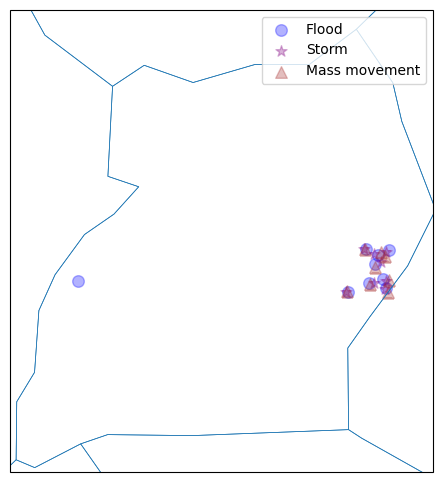

In [116]:
f, axes = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(6, 6))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes, linewidth=0.5)
for hazard in df_all_locs.keys() : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    x_values = add_jitter(df_all_locs[hazard].geometry.x)
    y_values = add_jitter(df_all_locs[hazard].geometry.y)
    
    axes.scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )

# Set the focus on Uganda
axes.set_xlim([29.5, 35])  # Longitude limits
axes.set_ylim([-1.5, 4.5])  # Latitude limits
axes.legend(fontsize=10)

plt.show()